![hslu_logo.png](img/hslu_logo.png)

## Week 02

<hr style="border:1px solid black">

# Excercise: Multi Layer Perceptron with PyTorch
---
---
This excercise is to illustrate a first classification problem using a multi-layer-perceptron. In other words it is a feed forward network with a set of fully connected layers. The input data can be choosen to be MNIST or FashionMNIST

### Import necessary packages

In [1]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from utils import read_data, plot_img, plot_tiles, plot_error, plot_cost

#### Download dataset (MNIST or FashionMNIST)

In [2]:
#data is save in storage_path (use same path for different SW)
training_data, test_data, labels_map = read_data(data_type='FashionMNIST', storage_path='../SW01/data')

#to access the images
print(f'training data shape {training_data.data.shape} and type {training_data.data.dtype} ')
print(f'test data shape {test_data.data.shape} and type {test_data.data.dtype} ')

#to access the labels
print(f'training data shape {training_data.targets.shape} and type {training_data.targets.dtype} ')
print(f'test data shape {test_data.targets.shape} and type {test_data.targets.dtype} ')
print(f'categories: {labels_map}')

training data shape torch.Size([60000, 28, 28]) and type torch.uint8 
test data shape torch.Size([10000, 28, 28]) and type torch.uint8 
training data shape torch.Size([60000]) and type torch.int64 
test data shape torch.Size([10000]) and type torch.int64 
categories: {0: 'T-Shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}


#### Organization of data

In [3]:
#to access direclty the images
print('data shape and type:')
print(training_data.data.shape)
print(training_data.data.dtype)

#to access directly the lables
print('\ncategory labels with shape and type:')
print(torch.unique(training_data.targets))
print(training_data.targets.shape)
print(training_data.targets.dtype)

data shape and type:
torch.Size([60000, 28, 28])
torch.uint8

category labels with shape and type:
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
torch.Size([60000])
torch.int64


#### Plot sample images

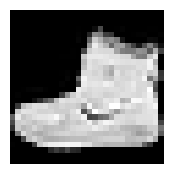

In [4]:
plot_img(training_data.data[0], figure_size = [2,2])

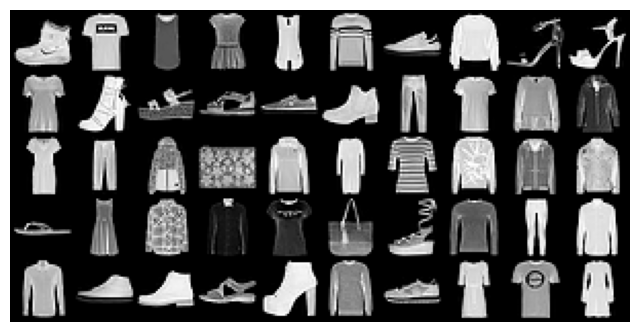

In [5]:
#plot categories mixed
plot_tiles(training_data.data, 10, 5)

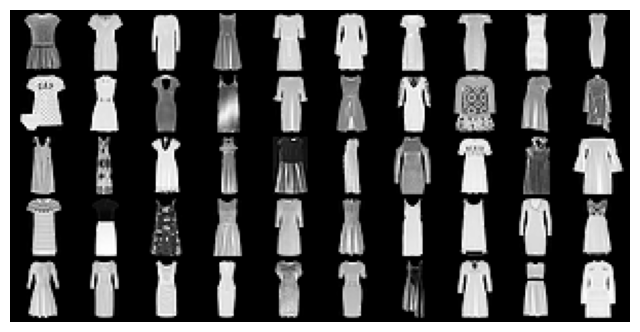

In [6]:
#plot only certain categorie
label = 3
plot_tiles(training_data.data[training_data.targets == label], 10,5)

#### Define the neural network

In [7]:
class MultiLayerPerceptron:
    """
    MLP class handling the layers and doing all propagation and back propagation steps
    all hidden layers are dense (with ReLU activation) and the last layer is softmax
    """
    def __init__(self, num_input, num_hidden, num_output):
        """
        constructor

        Arguments:
        list_num_neurons -- list of layer sizes including in- and output layer
        
        """
        self.model = torch.nn.Sequential(
            torch.nn.Linear(num_input, num_hidden),
            ### START YOUR CODE ###
            torch.nn.ReLU(),     # activation function of hidden layer
            torch.nn.Linear(num_hidden, num_output),  # output layer
            ### END YOUR CODE ###*
        )
        
        self.cost_fn = torch.nn.CrossEntropyLoss(reduction='mean')

        #used to save results
        self.result_data = torch.tensor([])
        
    def propagate(self, X):
        """
        calculates the function estimation based on current parameters [W,B]
        """    
        self.Y_pred = self.model(X)
           
     
    def back_propagate(self, cost):
        """
        calculates the backpropagation results based on expected output y
        this function must be performed AFTER the corresponding propagte step
        """    
        self.model.zero_grad()
        
        cost.backward()
 

    def calc_cost(self, Y):
        """
        calculates the MSE loss function
        """
        cost = self.cost_fn(self.Y_pred, Y)
        
        return cost
    
        
        
    def gradient_descend(self, alpha):
        """
        does the gradient descend based on results from last back_prop step with learning rate alpha
        """
        with torch.no_grad():
            for param in self.model.parameters():
                param -= alpha * param.grad
            
     
        
    def calc_error(self, Y):
        """
        get error information
        """
        m = Y.shape[0]

        Y_pred_argmax = torch.argmax(self.Y_pred, dim=1)
        train_error = torch.sum(Y != Y_pred_argmax) / m

        return train_error


    def save_training_data(self, data):
        """
        save training and validation curves
        """
        #determine the train loss and error
        self.propagate(data['X_train'])
        cost_train = self.calc_cost(data['Y_train'])
        error_train = self.calc_error(data['Y_train'])
        #calculate validation loss and error
        self.propagate(data['X_val'])
        cost_val = self.calc_cost(data['Y_val'])
        error_val = self.calc_error(data['Y_val'])

        #safe the results
        res = torch.tensor([[cost_train.item(), error_train.item(), cost_val.item(), error_val.item()]])
        self.result_data = torch.cat((self.result_data, res), 0)
        
        
    def optimize(self, data, epochs, alpha, debug=0):
        """
        performs epochs number of gradient descend steps and appends result to output array

        Arguments:
        data -- dictionary with data
        epochs -- number of epochs
        alpha -- learning rate
        debug -- False (default)/True; get info on each gradient descend step
        """
        
        # save results before 1st step
        for i0 in range(0, epochs):
            #save the data at the beginning of the step
            self.save_training_data(data)
            #do prediction
            self.propagate(data['X_train'])
            #determine the loss 
            cost = self.calc_cost(data['Y_train'])
            #determine the error
            self.back_propagate(cost)
            #do the correction step
            self.gradient_descend(alpha)
            #calculate the error
            error = self.calc_error(data['Y_train'])

            if debug and np.mod(i0, debug) == 0:
                print('step %r, train cost %1.3f, train error %1.3f, val cost %1.3f, val error %1.3f' % \
                     (i0, self.result_data[-1,0], self.result_data[-1,1], self.result_data[-1,2], self.result_data[-1,3]))

        #save final performance
        self.save_training_data(data)            
            

In [8]:
#normalize data: original data is overwritten
data_min, data_max = torch.min(training_data.data), torch.max(training_data.data)
print('original min-max values are: %r, %r and type %r' % (data_min.item(), data_max.item(), data_min.dtype))

normalize_tpye = 0

if normalize_tpye == 0:
    #min-max-rescaling
    training_data.data = (training_data.data.float() - data_min) / (data_max - data_min)    
    test_data.data = (test_data.data.float() - data_min) / (data_max - data_min)   
else:
    #min-max-normalization
    training_data.data = 2*(training_data.data.float() - data_min) / (data_max - data_min) - 1
    test_data.data = 2*(test_data.data.float() - data_min) / (data_max - data_min) - 1 

data_min, data_max = torch.min(training_data.data), torch.max(training_data.data)
print('now min-max values are: %r, %r and type %r' % (data_min.item(), data_max.item(), data_min.dtype))


original min-max values are: 0, 255 and type torch.uint8
now min-max values are: 0.0, 1.0 and type torch.float32


#### Define X and Y values and do optimization

Sequential(
  (0): Linear(in_features=784, out_features=100, bias=True)
  (1): ReLU()
  (2): Linear(in_features=100, out_features=10, bias=True)
)
step 0, train cost 2.311, train error 0.902, val cost 2.310, val error 0.903
step 100, train cost 2.084, train error 0.491, val cost 2.084, val error 0.494
step 200, train cost 1.840, train error 0.393, val cost 1.842, val error 0.400
step 300, train cost 1.599, train error 0.365, val cost 1.603, val error 0.371
step 400, train cost 1.406, train error 0.351, val cost 1.412, val error 0.357
step 500, train cost 1.262, train error 0.344, val cost 1.269, val error 0.349
step 600, train cost 1.155, train error 0.338, val cost 1.163, val error 0.344
step 700, train cost 1.074, train error 0.332, val cost 1.083, val error 0.340
step 800, train cost 1.011, train error 0.325, val cost 1.022, val error 0.336
step 900, train cost 0.962, train error 0.317, val cost 0.973, val error 0.326


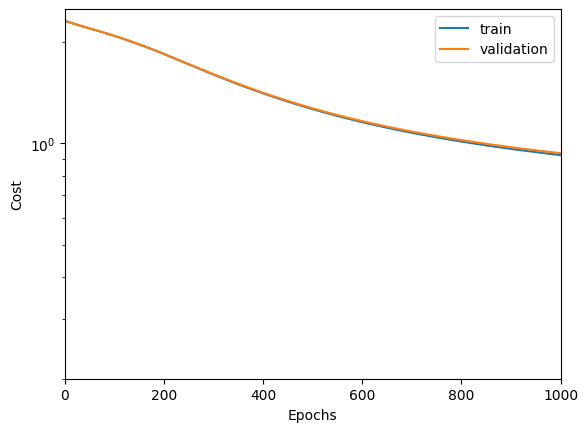

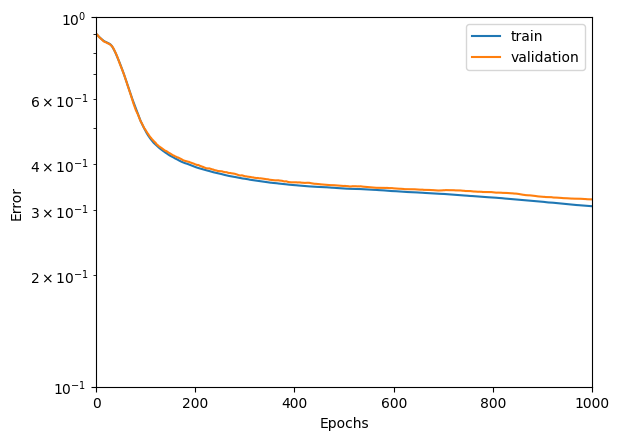

In [11]:
#input is flattend to n x 784
data_X = training_data.data.flatten(1)
data_X_test = test_data.data.flatten(1)
#labels are direclty supported by pytorch
data_Y = training_data.targets
data_Y_test = test_data.targets

data = {'X_train' : data_X, 'Y_train' : data_Y, \
         'X_val' : data_X_test, 'Y_val' : data_Y_test}

num_input = data_X.shape[1]
num_output = len(torch.unique(data_Y))
num_hidden = 100

mlp = MultiLayerPerceptron(num_input, num_hidden, num_output)

print(mlp.model)

mlp.optimize(data, 1000, 0.005, 100)

#plot the results
plot_cost(mlp, y_range = [2e-1, 2.5])
plot_error(mlp, y_range = [1e-1, 1])

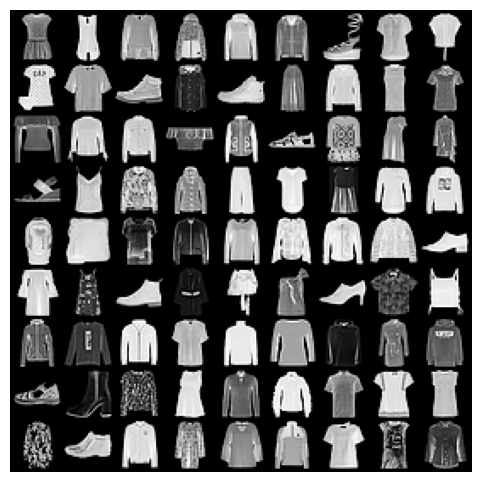

[0 3 2 2 2 2 8 0 0]
[6 0 7 2 7 0 2 3 0]
[0 2 2 8 2 7 2 0 4]
[9 0 2 2 0 0 0 6 4]
[3 2 0 6 2 2 2 2 7]
[6 0 7 5 6 0 7 0 2]
[2 6 2 0 4 6 6 3 4]
[7 5 2 0 6 4 0 0 0]
[4 7 2 4 2 4 0 0 2]


In [10]:
y_pred = torch.argmax(mlp.model(data_X),1)

#select a number of false classifications (rows x cols) to plot
num_sel = 9

plot_tiles(training_data.data[y_pred != data_Y], num_sel, num_sel, figure_size = [6,6])

for i0 in range(0, num_sel):
    print(y_pred[y_pred != data_Y][i0*num_sel:(i0+1)*num_sel].numpy())